# Tugas - Medical Cost Prediction

| Nama | NRP |
|------|-----|
| Hilal Tsabitul Azmi Arba'i | 5054251008 |

## Deskripsi Tugas

Pada tugas ini, kita akan menggunakan Medical Cost Personal Dataset dari Kaggle.

Dataset:
- https://www.kaggle.com/mirichoi0218/insurance

Target yang diprediksi adalah `charges`.

Model yang digunakan:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Decision Tree Regressor
6. Support Vector Regression


# 1. Persiapan Dataset dan Eksplorasi Awal

In [14]:
# Import library yang dibutuhkan.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split


In [15]:
# Load dataset.
# Sesuaikan nama file dengan file dataset yang digunakan.
data_raw = pd.read_csv("insurance.csv")

In [16]:
# Tampilkan beberapa baris pertama dataset.
data_raw.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
# Tampilkan informasi dataset.
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [18]:
# Periksa missing value.
data_raw.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

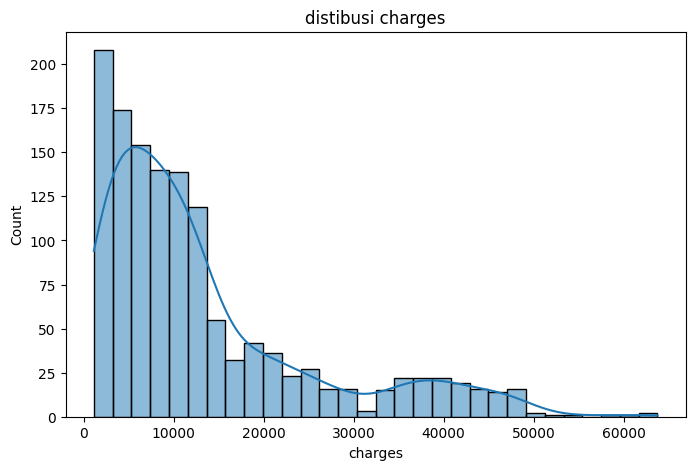

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(data_raw["charges"], kde=True)
plt.title("distibusi charges")
plt.show()


<Figure size 800x500 with 0 Axes>

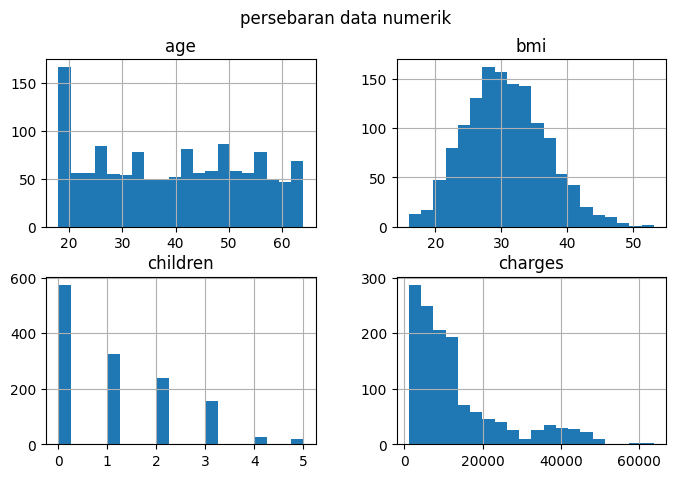

In [20]:
# Tampilkan statistik deskriptif fitur numerik.
data_numerik = data_raw.select_dtypes(include=[np.number])
plt.figure(figsize=(8,5))
data_numerik.hist(figsize=(8,5), bins=20, density=False)
plt.suptitle("persebaran data numerik")
plt.show()

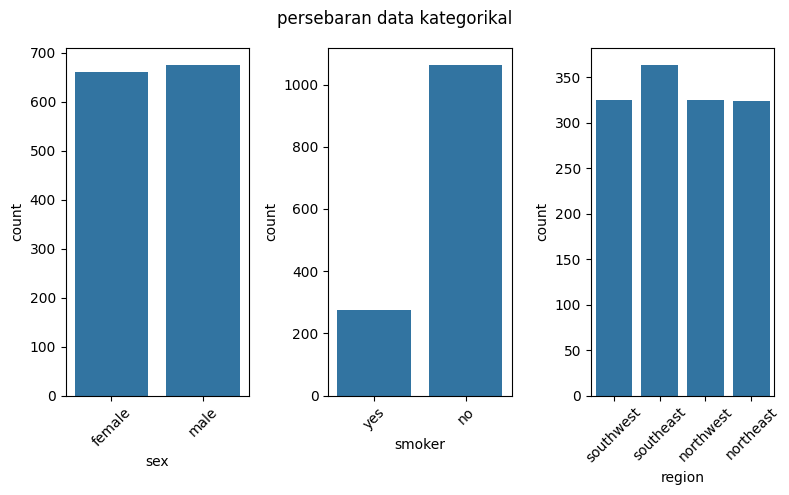

In [21]:
data_kategorikal = data_raw.select_dtypes(include=['object', 'category'])

fig, axes = plt.subplots(1, len(data_kategorikal.columns), figsize=(8,5))
for ax, col in zip(axes, data_kategorikal.columns):
    sns.countplot(data=data_raw, x=col, ax=ax)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle("persebaran data kategorikal")
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) sederhana yang diperlukan.


# 2. Preprocessing

Pisahkan fitur numerik dan kategorikal. Gunakan OneHotEncoder untuk fitur kategorikal.

Model Linear Regression, Polynomial Regression, Ridge, Lasso, dan SVR menggunakan data yang telah di-scaling. Decision Tree Regressor tidak memerlukan scaling.


In [22]:
# Pisahkan fitur (X) dan target (y).
X = data_raw.drop(columns=["charges"])
y = data_raw["charges"]

print("Bentuk X:", X.shape)
print("Bentuk y:", y.shape)
print(X.head())


Bentuk X: (1338, 6)
Bentuk y: (1338,)
   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest


In [23]:
# Identifikasi kolom numerik dan kategorikal.
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Fitur numerik:", numeric_features)
print("Fitur kategorikal:", categorical_features)


Fitur numerik: ['age', 'bmi', 'children']
Fitur kategorikal: ['sex', 'smoker', 'region']


In [24]:
# Bagi data menjadi train set dan test set.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)


X_train: (1070, 6) | X_test: (268, 6)
y_train: (1070,) | y_test: (268,)


In [25]:
# Buat preprocessing untuk fitur numerik dan kategorikal.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Untuk model linear/Ridge/Lasso/SVR: numerik di-scaling, kategorikal di-one-hot.
preprocessor_scaled = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Untuk Decision Tree: tidak perlu scaling, numerik dilewatkan apa adanya.
preprocessor_tree = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

print(preprocessor_scaled)
print(preprocessor_tree)


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'bmi', 'children']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])
ColumnTransformer(transformers=[('num', 'passthrough',
                                 ['age', 'bmi', 'children']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])


# 3. Eksperimen Model

## 3.1 Linear Regression

Bangun model Linear Regression menggunakan data hasil preprocessing.


In [26]:
# Inisialisasi dan latih Linear Regression.
from sklearn.linear_model import LinearRegression

model_lin = Pipeline([
    ("preprocess", preprocessor_scaled),
    ("regressor", LinearRegression())
])
model_lin.fit(X_train, y_train)
print("Linear Regression selesai dilatih.")


Linear Regression selesai dilatih.


In [27]:
# Lakukan prediksi pada test set.
y_pred_lin = model_lin.predict(X_test)
print(y_pred_lin[:5])


[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656]


## 3.2 Polynomial Regression

Gunakan PolynomialFeatures. Tentukan degree berdasarkan eksperimen.


In [28]:
# Buat fitur polynomial dan latih model.
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# degree=2 hasil eksperimen (degree lebih besar rawan overfitting).
model_poly = Pipeline([
    ("preprocess", preprocessor_scaled),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("regressor", LinearRegression())
])
model_poly.fit(X_train, y_train)
print("Polynomial Regression (degree=2) selesai dilatih.")


Polynomial Regression (degree=2) selesai dilatih.


In [29]:
# Lakukan prediksi pada test set.
y_pred_poly = model_poly.predict(X_test)
print(y_pred_poly[:5])


[11215.72133573  6055.22653741 33306.27444924 10833.80112228
 29082.43036144]


## 3.3 Ridge Regression

Gunakan Ridge Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [30]:
# Inisialisasi dan latih Ridge Regression.
from sklearn.linear_model import Ridge

# alpha=1.0 hasil eksperimen.
model_ridge = Pipeline([
    ("preprocess", preprocessor_scaled),
    ("regressor", Ridge(alpha=1.0))
])
model_ridge.fit(X_train, y_train)
print("Ridge Regression selesai dilatih.")


Ridge Regression selesai dilatih.


In [31]:
# Lakukan prediksi pada test set.
y_pred_ridge = model_ridge.predict(X_test)
print(y_pred_ridge[:5])


[ 8979.95466915  7079.65062176 36792.69449533  9468.40383721
 26924.2040913 ]


## 3.4 Lasso Regression

Gunakan Lasso Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [32]:
# Inisialisasi dan latih Lasso Regression.
from sklearn.linear_model import Lasso

# alpha=1.0 hasil eksperimen, max_iter dinaikkan agar konvergen.
model_lasso = Pipeline([
    ("preprocess", preprocessor_scaled),
    ("regressor", Lasso(alpha=1.0, max_iter=10000))
])
model_lasso.fit(X_train, y_train)
print("Lasso Regression selesai dilatih.")


Lasso Regression selesai dilatih.


In [33]:
# Lakukan prediksi pada test set.
y_pred_lasso = model_lasso.predict(X_test)
print(y_pred_lasso[:5])


[ 8964.99606188  7064.32364784 36846.39348515  9453.48079986
 26967.0401981 ]


## 3.5 Decision Tree Regressor

Gunakan Decision Tree Regressor. Eksperimen dapat dilakukan pada `max_depth` dan `min_samples_leaf`.


In [34]:
# Inisialisasi dan latih Decision Tree Regressor.
from sklearn.tree import DecisionTreeRegressor

# max_depth dan min_samples_leaf hasil eksperimen untuk menahan overfitting.
model_tree = Pipeline([
    ("preprocess", preprocessor_tree),
    ("regressor", DecisionTreeRegressor(max_depth=8, min_samples_leaf=4, random_state=42))
])
model_tree.fit(X_train, y_train)
print("Decision Tree Regressor selesai dilatih.")


Decision Tree Regressor selesai dilatih.


In [35]:
# Lakukan prediksi pada test set.
y_pred_tree = model_tree.predict(X_test)
print(y_pred_tree[:5])


[13552.4825056   4927.79033279 28492.564524   13552.4825056
 33266.0987875 ]


## 3.6 Support Vector Regression

Gunakan SVR dengan data yang telah di-scaling. Tentukan parameter berdasarkan eksperimen.


In [36]:
# Inisialisasi dan latih SVR.
from sklearn.svm import SVR

# Data sudah di-scaling via preprocessor_scaled. C dan epsilon hasil eksperimen.
model_svr = Pipeline([
    ("preprocess", preprocessor_scaled),
    ("regressor", SVR(kernel="rbf", C=1000.0, epsilon=500.0))
])
model_svr.fit(X_train, y_train)
print("SVR selesai dilatih.")


SVR selesai dilatih.


In [37]:
# Lakukan prediksi pada test set.
y_pred_svr = model_svr.predict(X_test)
print(y_pred_svr[:5])


[ 9576.97100532  5326.26403847 24304.27499179  9571.96375523
 19870.55440283]


# 4. Evaluasi Model

In [38]:
# Hitung MAE, MSE, RMSE, dan R² untuk setiap model.
# Sajikan hasil dalam satu tabel perbandingan.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

preds = {
    "Linear": y_pred_lin,
    "Polynomial": y_pred_poly,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "DecisionTree": y_pred_tree,
    "SVR": y_pred_svr,
}

rows = []
for name, y_pred in preds.items():
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)
    rows.append([name, mae, mse, rmse, r2])

hasil = pd.DataFrame(rows, columns=["Model", "MAE", "MSE", "RMSE", "R2"]).set_index("Model")
hasil


,MAE,MSE,RMSE,R2
Model,,,,
Linear,4181.194474,3.359692e+07,5796.284659,0.783593
Polynomial,2729.500134,2.071281e+07,4551.132385,0.866583
Ridge,4186.913072,3.362027e+07,5798.298795,0.783443
Lasso,4182.081076,3.360584e+07,5797.054261,0.783536
DecisionTree,2637.393715,2.446479e+07,4946.189945,0.842415
SVR,3206.725741,4.678536e+07,6839.982219,0.698643


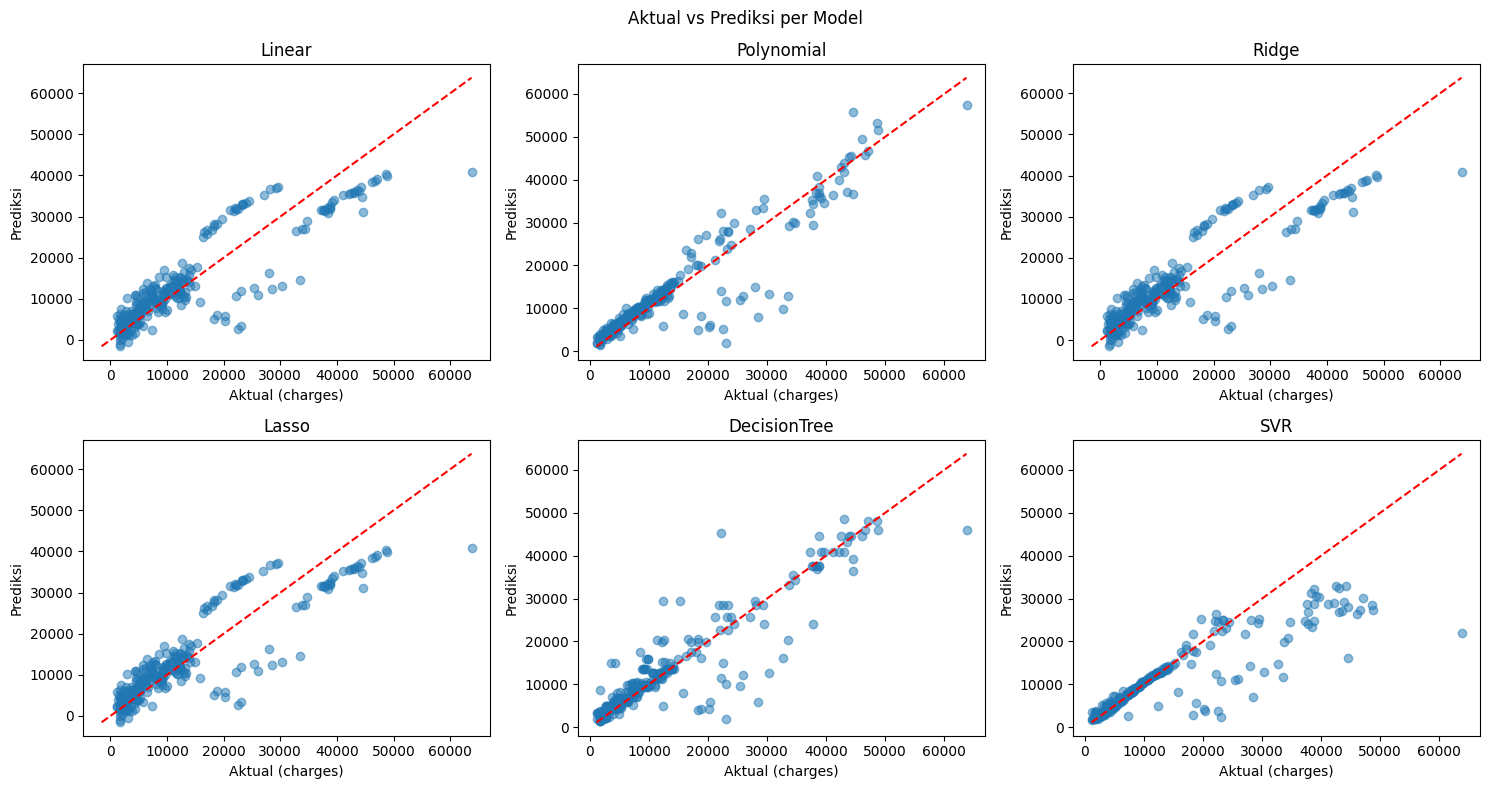

In [39]:
# Buat visualisasi perbandingan nilai aktual dan prediksi jika diperlukan.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_test, y_pred, alpha=0.5)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--")
    ax.set_xlabel("Aktual (charges)")
    ax.set_ylabel("Prediksi")
    ax.set_title(name)

plt.suptitle("Aktual vs Prediksi per Model")
plt.tight_layout()
plt.show()


# 5. Analisis

Dari tabel evaluasi, Polynomial Regression menghasilkan performa terbaik dengan MAE sebesar 2729,50, RMSE sebesar 4551,13, dan nilai R² sebesar 0,8666. Nilai tersebut menunjukkan bahwa model mampu menjelaskan sekitar 86,66% variasi biaya medis (charges) pada data uji. Model terbaik berikutnya adalah Decision Tree Regressor dengan R² sebesar 0,8424 dan RMSE sebesar 4946,19. Sementara itu, Linear Regression, Ridge Regression, dan Lasso Regression menghasilkan performa yang hampir identik dengan nilai R² sekitar 0,7835, menunjukkan bahwa penambahan regularisasi menggunakan Ridge dan Lasso tidak memberikan peningkatan yang signifikan. Hal ini kemungkinan disebabkan jumlah fitur yang relatif sedikit serta tingkat multikolinearitas yang rendah pada dataset. Di sisi lain, Support Vector Regression (SVR) menunjukkan performa terendah dengan nilai R² sebesar 0,6986 dan RMSE sebesar 6839,98 meskipun telah menggunakan proses scaling dan parameter hasil eksperimen. Hasil ini mengindikasikan bahwa hubungan antara fitur dan target pada dataset lebih efektif dimodelkan menggunakan pendekatan non-linear seperti Polynomial Regression dibandingkan pendekatan linear maupun SVR. turn4search7


# 6. Kesimpulan dan Saran

Kesimpulan: Berdasarkan hasil eksperimen enam model regresi, dapat disimpulkan bahw Polynomial Regression dengan degree 2 merupakan model terbaik untuk kasus prediksi biaya medis pada Medical Cost Personal Dataset. Model ini menghasilkan nilai error paling rendah dan nilai R² paling tinggi dibandingkan model lainnya, sehingga mampu memberikan prediksi yang lebih akurat terhadap nilai charges. Hasil tersebut menunjukkan bahwa hubungan antara variabel prediktor dengan biaya medis tidak sepenuhnya bersifat linear, sehingga penambahan fitur polinomial mampu membantu model menangkap pola yang lebih kompleks. Selain itu, proses preprocessing berupa OneHotEncoder untuk fitur kategorikal dan StandardScaler untuk fitur numerik terbukti penting untuk meningkatkan performa sebagian besar model yang digunakan.

saran: Untuk penelitian atau eksperimen lanjutan, disarankan melakukan proses hypeparameter tuning yang lebih sistematis menggunakan Grid Search atau Cross Validation agar diperoleh kombinasi parameter yang lebih optimal. Pada Polynomial Regression dapat dicoba degree yang berbeda, seperti degree 3, untuk melihat pengaruh kompleksitas model terhadap performa prediksi. Selain itu, parameter Ridge, Lasso, Decision Tree, dan SVR juga dapat dieksplorasi lebih lanjut untuk memperoleh hasil yang lebih baik. Penggunaan teknik validasi silang (cross-validation) dan penambahan analisis eksploratif yang lebih mendalam juga disarankan agar model yang dihasilkan memiliki kemampuan generalisasi yang lebih baik pada data baru.
